In [ ]:
#########################################################################
###########------- Smart Data Consulting  ------------###################
#########################################################################
# Capacitador: Julio César Bernal Fernández
# email: juliobf08@gmail.com
# Tema : Series de Tiempo - LSTM
# version: 1.0
#########################################################################

In [1]:
!python -m pip install statsmodels

In [2]:
!statsmodels --version

/bin/bash: line 1: statsmodels: command not found


In [3]:
!pip install --upgrade statsmodels

In [ ]:
# Nos vinculamos a nuestro drive, para poder usar facilmente GColab
from google.colab import drive
drive.mount('/content/drive')

In [4]:
# Parte 1 - Importamos las librerias necesarias.

# Importación de las librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Parte 2 - Tratamiento de datos y generacion de los datasets.

In [ ]:
# Notas:
# parse_dates: Especifica la columna que contiene la información de fecha y hora.
# index_col:   El índice debe ser la variable que representa la información de fecha y hora.
# date_parser: Especifica una función que convierte una cadena de entrada en variable de fecha y hora. Por defecto, Pandas lee los datos en formato "AAAA-MM-DD HH: MM: SS".
# Si los datos no están en este formato, el formato debe definirse manualmente.

In [5]:
# Importamos el set de datos!

df = pd.read_csv('Aplicacion_UrbanismoTransportePublico.csv',
                parse_dates=['Fecha'],
                dayfirst=True,
                index_col='Fecha')
df

,Trafico
Fecha,
2012-08-25,76
2012-08-26,88
2012-08-27,62
2012-08-28,58
2012-08-29,60
...,...
2014-09-21,9102
2014-09-22,14116
2014-09-23,13304


In [6]:
# Revisamos la cantidad de elementos del dataset!
df.shape

(762, 1)

In [7]:
# Vemos un poco la estructura de datos!
df.head(10)

,Trafico
Fecha,
2012-08-25,76
2012-08-26,88
2012-08-27,62
2012-08-28,58
2012-08-29,60
2012-08-30,74
2012-08-31,78
2012-09-01,112
2012-09-02,118


In [8]:
# En caso de ser necesario ordenamos los registros por fecha.
df.sort_values('Fecha', inplace=True, ascending=True)

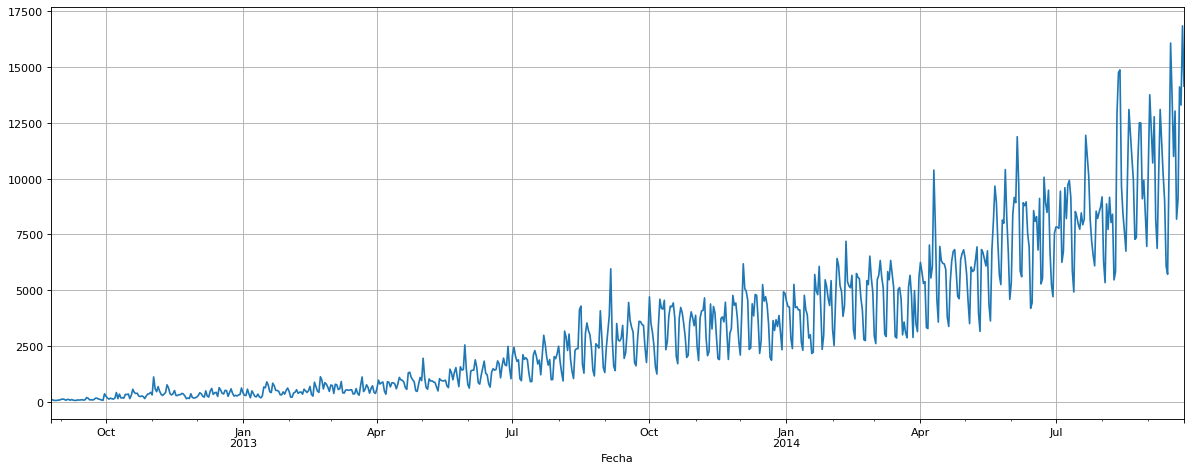

In [9]:
# Visualizamos la informacion del conjunto de datos!
plt.figure(num=None, figsize=(15, 6), dpi=80, facecolor='w', edgecolor='k')
df['Trafico'].plot()
plt.tight_layout()
plt.grid()
plt.show()

# Conclusiones:
# Zt = T + e + C + a
# Tendencia deterministica de tipo lineal creciente!
# Estacionalidad muy marcada!

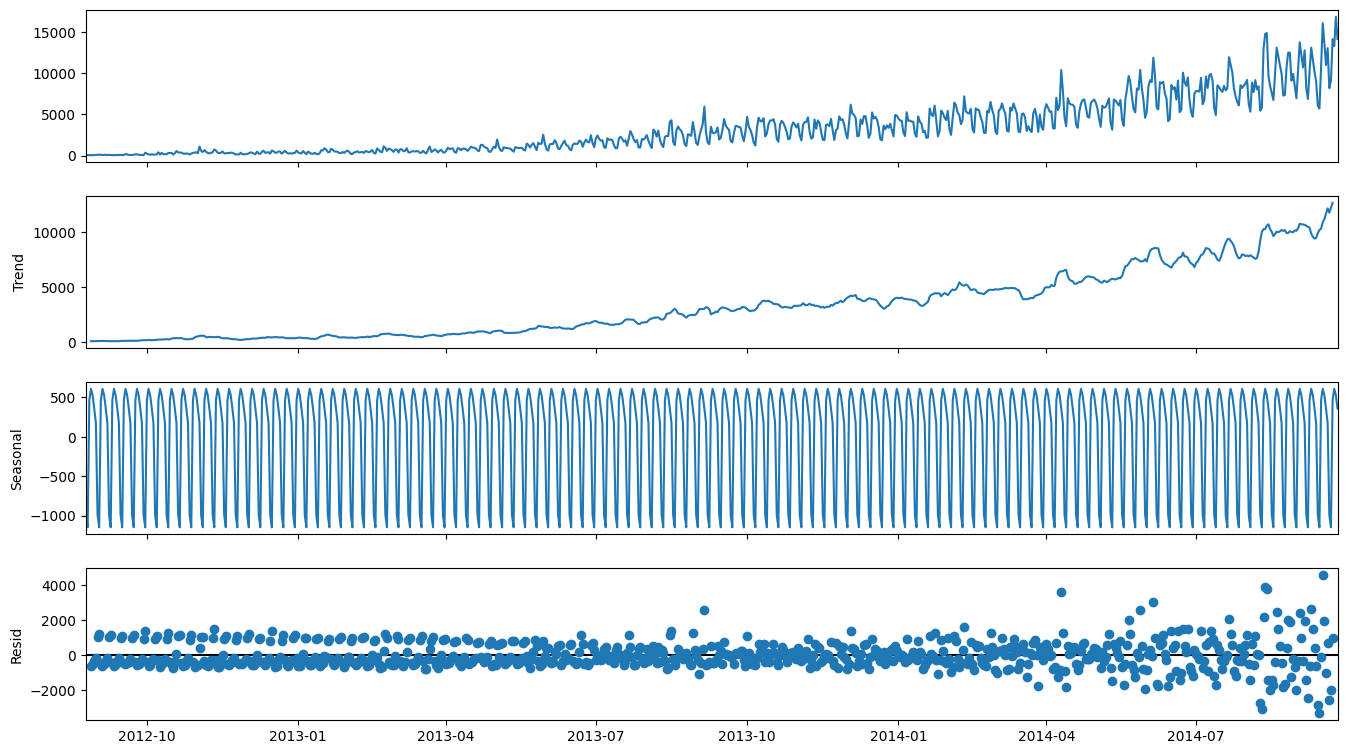

In [10]:
# Descomposición de la serie de tiempo

import statsmodels.api as sm
import matplotlib.pyplot as plt
res = sm.tsa.seasonal_decompose(df)
fig = res.plot()
fig.set_figheight(8)
fig.set_figwidth(15)
plt.show()

In [ ]:
# Deep Learning --> Machine Learning!

In [ ]:
# Machine Learning , X  -->  y
# Train - Test

# En series de tiempo generalmente se hace un particion distinta!
# Seamos cuidadosos y no es igual al train test split!
train, test = df.iloc[0:-100], df.iloc[-100:len(df)]
print(len(train), len(test))


In [ ]:
test.head(5)

In [ ]:
# Importante!
# En series de tiempo es necesario escalar las variable o caracteristicas!
# Para escalar puedes usar normalización,estandarización u otro tipo de escalado.
train_max = train.max()
train_min = train.min()

In [ ]:
train_min

In [ ]:
# Normalizamos los set de datos, train y test!
# Pueden utilizar la metodologia de escalamiento que deseen!
train_set_scaled = (train - train_min)/(train_max - train_min)
test_set_scaled = (test - train_min)/(train_max - train_min)

In [ ]:
# Revisamos el escalado!
train_set_scaled.head(10)

In [ ]:
train_set_scaled.shape

(662, 1)

In [ ]:
# Definimos la funcion de la arquitectura X - y.
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

In [ ]:
# Definimos un time_step y procedemos a crear los dataframes!
time_steps = 1 # Comencemos un vector unitario

X_train, y_train = create_dataset(train_set_scaled, train_set_scaled.Trafico , time_steps)
X_test,  y_test  = create_dataset(test_set_scaled,  test_set_scaled.Trafico, time_steps)

In [ ]:
# reshape input debe ser 3D para las LSTM's: [samples, timesteps, features]
X_train.shape

In [ ]:
X_train[653],X_train[654]

In [ ]:
y_train[653]

In [ ]:
# Parte 3 - Creamos la arquitecura de Red Neuronal Recurrente!

In [ ]:
X_train.shape[2]

In [ ]:
# Importando de keras las librerias mas importantes!
from keras.models import Sequential # Arquitectura de red neuronal!
from keras.layers import Dense      # Capa densa!
from keras.layers import LSTM       # Capa recurrente
from keras.layers import Dropout    # Evita el overfitting (Inactiva algunas neuronas)

def lstm_architecture(X_data,rate_dropout):
    # Inicializando the RNN
    model = Sequential()

    # 1ra capa LSTM y Dropout para regularización.
    # input_shape (amplitude,1)
    model.add(LSTM(units = 250, return_sequences = True, input_shape=(X_data.shape[1], X_data.shape[2])))
    # 20% de las neuronas serán ignoradas durante el training (20%xNodos = 10)
    # Para hacer menos probable el overfiting
    model.add(Dropout(rate=rate_dropout))

    # 2da capa LSTM y Dropout para regularización.
    model.add(LSTM(units = 250, return_sequences = True))
    model.add(Dropout(rate=rate_dropout))

    # 3ra capa LSTM y Dropout para regularización.
    model.add(LSTM(units = 250, return_sequences = True))
    model.add(Dropout(rate=rate_dropout))

    # 4ta capa LSTM y Dropout para regularización.
    model.add(LSTM(units = 250, return_sequences = False))
    model.add(Dropout(rate=rate_dropout))

    # Capa de Salida!
    model.add(Dense(units = 1))

    # Resumen del modelo!
    model.summary()

    return model

In [ ]:
import datetime
print('Iniciando a las: ', datetime.datetime.now())
print("...")

# Compiling the RNN
model_1 = lstm_architecture(X_data=X_train,rate_dropout=0.2)
model_1.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [ ]:
# Ejecutamos la RNN!

history = model_1.fit(X_train,
                    y_train,
                    epochs=100,
                    batch_size=32,
                    shuffle=False)

print("...")
print('Terminando a las: ', datetime.datetime.now())

In [ ]:
# Revisamos algunos parametros de ajuste del modelo!
plt.plot(history.history['loss'], label='train')
plt.legend();
plt.show()

In [ ]:
# Predecimos sobre la data de test!
y_pred = model_1.predict(X_test)

In [ ]:
# Regresamos la informacion a los valores originales!
y_test = y_test*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores reales de test!
y_pred = y_pred*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores pronosticados para validar!
y_train = y_train*(train_max[0] - train_min[0]) + train_min[0]  # 652 valores de entrenamiento!

In [ ]:
# Visualizamos los resultados!
plt.figure(num=None, figsize=(15, 6), dpi=80, facecolor='w', edgecolor='k')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test.flatten(), marker='.', label="true")
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_pred.flatten(), 'r', marker='.', label="prediction")
plt.plot(np.arange(0, len(y_train)), y_train.flatten(), 'g', marker='.', label="history")
plt.ylabel('Count')
plt.xlabel('Time Step')
plt.legend()
plt.show()

In [ ]:
# Vemos algunos indicadores del ajuste!
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'RMSE: ',rmse)

# Definimos y calculamos el MAPE (mean_absolute_percentage_error)
y_test, y_pred = np.array(y_test), np.array(y_pred)
print(f'MAPE: ',np.mean(np.abs((y_test - y_pred) / y_test)) * 100)


In [ ]:
# Tarea:
# Con el objetivo de ser mas preciso con la red neuronal, probar:
# 1) Aumentar el numero de capas ocultas.
# 2) Ir variando el numero de neuronas por capa oculta.
# 3) el dropout midificarlo, dejar inactivas el 20% de las neuronas por capa es demasiado.
# 4) El numero de epoch es poco para entrenar y parametrizar 2 MM de parametros.
# 5) Probar entre 40 y 64 el bach size.

In [ ]:
# Definimos un time_step y procedemos a crear los dataframes!
time_steps = 7 # Porque tengo data diaria y necesito estacionalidad de la semana!

X_train, y_train = create_dataset(train_set_scaled, train_set_scaled.Trafico , time_steps)
X_test,  y_test  = create_dataset(test_set_scaled,  test_set_scaled.Trafico, time_steps)

In [ ]:
model_2 = lstm_architecture(X_data=X_train,rate_dropout=0.2)
model_2.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [ ]:
# Ejecutamos la RNN!

history = model_2.fit(X_train,
                    y_train,
                    epochs=100,
                    batch_size=32,
                    shuffle=False)

print("...")
print('Terminando a las: ', datetime.datetime.now())

In [ ]:
# Revisamos algunos parametros de ajuste del modelo!
plt.plot(history.history['loss'], label='train')
plt.legend();
plt.show()

In [ ]:
# Predecimos sobre la data de test!
y_pred = model_2.predict(X_test)

# Regresamos la informacion a los valores originales!
y_test = y_test*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores reales de test!
y_pred = y_pred*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores pronosticados para validar!
y_train = y_train*(train_max[0] - train_min[0]) + train_min[0]  # 652 valores de entrenamiento!

# Visualizamos los resultados!
plt.figure(num=None, figsize=(15, 6), dpi=80, facecolor='w', edgecolor='k')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test.flatten(), marker='.', label="true")
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_pred.flatten(), 'r', marker='.', label="prediction")
plt.plot(np.arange(0, len(y_train)), y_train.flatten(), 'g', marker='.', label="history")
plt.ylabel('Count')
plt.xlabel('Time Step')
plt.legend()
plt.show()

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'RMSE: ',rmse)

# Definimos y calculamos el MAPE (mean_absolute_percentage_error)
y_test, y_pred = np.array(y_test), np.array(y_pred)
print(f'MAPE: ',np.mean(np.abs((y_test - y_pred) / y_test)) * 100)

## Probando distintos hiperparámetros

In [ ]:
# Definimos un time_step y procedemos a crear los dataframes!
time_steps = 30 # Porque tengo data diaria y necesito estacionalidad de la semana!

X_train, y_train = create_dataset(train_set_scaled, train_set_scaled.Trafico , time_steps)
X_test,  y_test  = create_dataset(test_set_scaled,  test_set_scaled.Trafico, time_steps)

In [ ]:
model_3 = lstm_architecture(X_data=X_train,rate_dropout=0.2)
model_3.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [ ]:
# Ejecutamos la RNN!

history = model_3.fit(X_train,
                    y_train,
                    epochs=100,
                    batch_size=32,
                    shuffle=False)

print("...")
print('Terminando a las: ', datetime.datetime.now())

In [ ]:
# Revisamos algunos parametros de ajuste del modelo!
plt.plot(history.history['loss'], label='train')
plt.legend();
plt.show()

In [ ]:
# Predecimos sobre la data de test!
y_pred = model_3.predict(X_test)

# Regresamos la informacion a los valores originales!
y_test = y_test*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores reales de test!
y_pred = y_pred*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores pronosticados para validar!
y_train = y_train*(train_max[0] - train_min[0]) + train_min[0]  # 652 valores de entrenamiento!

# Visualizamos los resultados!
plt.figure(num=None, figsize=(15, 6), dpi=80, facecolor='w', edgecolor='k')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test.flatten(), marker='.', label="true")
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_pred.flatten(), 'r', marker='.', label="prediction")
plt.plot(np.arange(0, len(y_train)), y_train.flatten(), 'g', marker='.', label="history")
plt.ylabel('Count')
plt.xlabel('Time Step')
plt.legend()
plt.show()

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'RMSE: ',rmse)

# Definimos y calculamos el MAPE (mean_absolute_percentage_error)
y_test, y_pred = np.array(y_test), np.array(y_pred)
print(f'MAPE: ',np.mean(np.abs((y_test - y_pred) / y_test)) * 100)

## Feature Engineering

In [ ]:
# Importamos el set de datos!
df = pd.read_csv('Aplicacion_UrbanismoTransportePublico.csv',
                   parse_dates=['Fecha'],
                   index_col='Fecha')
df

In [ ]:
df.sort_values('Fecha', inplace=True, ascending=True)

In [ ]:
ma_day = [7, 30]

for ma in ma_day:
    column_name = f"MA({ma})"
    df[column_name] = df['Trafico'].rolling(ma).mean()
    #test_set_scaled[column_name] = test_set_scaled['Trafico'].rolling(ma).mean()

In [ ]:
df = df.dropna()

In [ ]:
# Hacemos la partición de la data en training y test para una serie de tiempo
train, test = df.iloc[0:-100], df.iloc[-100:len(df)]
print(len(train), len(test))

In [ ]:
train.head(10)

In [ ]:
#Escalamos nuestro dataset
train_min = train.min()
train_max = train.max()

train_min,train_max

In [ ]:
train_set_scaled = (train - train_min)/(train_max - train_min)
test_set_scaled = (test - train_min)/(train_max - train_min)

#Revisamos el escalado
train_set_scaled.head(10)

In [ ]:
# Definimos la funcion de la arquitectura X - y.
def create_dataset_multivariable(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

In [ ]:
# Definimos un time_step y procedemos a crear los dataframes!
time_steps = 7 # Porque tengo data diaria y necesito estacionalidad de la semana!

X_train, y_train = create_dataset(train_set_scaled, train_set_scaled.Trafico , time_steps)
X_test,  y_test  = create_dataset(test_set_scaled,  test_set_scaled.Trafico, time_steps)

In [ ]:
X_train.shape

In [ ]:
model_6 = lstm_architecture(X_data=X_train,rate_dropout=0.2)
model_6.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [ ]:
# Ejecutamos la RNN!

history = model_6.fit(X_train,
                    y_train,
                    epochs=100,
                    batch_size=32,
                    shuffle=False)

print("...")
print('Terminando a las: ', datetime.datetime.now())

In [ ]:
# Revisamos algunos parametros de ajuste del modelo!
plt.plot(history.history['loss'], label='train')
plt.legend();
plt.show()

In [ ]:
# Predecimos sobre la data de test!
y_pred = model_6.predict(X_test)

# Regresamos la informacion a los valores originales!
y_test = y_test*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores reales de test!
y_pred = y_pred*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores pronosticados para validar!
y_train = y_train*(train_max[0] - train_min[0]) + train_min[0]  # 652 valores de entrenamiento!

# Visualizamos los resultados!
plt.figure(num=None, figsize=(15, 6), dpi=80, facecolor='w', edgecolor='k')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test.flatten(), marker='.', label="true")
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_pred.flatten(), 'r', marker='.', label="prediction")
plt.plot(np.arange(0, len(y_train)), y_train.flatten(), 'g', marker='.', label="history")
plt.ylabel('Count')
plt.xlabel('Time Step')
plt.legend()
plt.show()